# 1. Portada

**Título del proyecto:** Análisis estadístico sobre hábitos saludables en jóvenes universitarios 
**Materia:** Inferencia Estadística 

**Introducción al problema:** La vida universitaria representa un periodo de transición crítica donde los estudiantes suelen modificar sus estilos de vida, muchas veces adoptando hábitos poco saludables. Este proyecto busca analizar estadísticamente cómo interactúan el sueño, la alimentación y la actividad física, para comprender su impacto en el bienestar general de la población estudiantil.

# 2. Introducción

**Problema de investigación:** El equipo de investigación ha sido convocado para analizar los factores que influyen en los hábitos de sueño, alimentación y actividad física en jóvenes universitarios[cite: 10]. La necesidad radica en identificar patrones comunes y causas probables que expliquen el deterioro en la calidad de vida durante la etapa académica[cite: 11].

**Justificación:** Comprender estas dinámicas es fundamental para generar un informe científico que oriente nuevas políticas de bienestar estudiantil en las instituciones de educación superior[cite: 11].

**Objetivos:**
* **Objetivo General:** Desarrollar una investigación estadística completa, identificando hipótesis relevantes y realizando inferencias válidas sobre los hábitos saludables de la población objetivo[cite: 14].
* **Objetivos Específicos:** 1. Simular y explorar un dataset representativo de jóvenes universitarios.
    2. Calcular probabilidades y modelar variables clave mediante distribuciones teóricas.
    3. Estimar parámetros poblacionales mediante intervalos de confianza.
    4. Aplicar pruebas de hipótesis para validar afirmaciones estadísticas.

# 3. Método Científico (Lección 1)

**Pregunta de investigación:** ¿Existe una diferencia significativa en las horas de sueño y el nivel de bienestar entre los estudiantes que mantienen buenos hábitos de actividad física y alimentación frente a los que no?

**Hipótesis:**
* **Hipótesis Nula ($H_0$):** No existe diferencia significativa en el promedio de horas de sueño entre los estudiantes que realizan actividad física regular (3 o más días) y los que no.
* **Hipótesis Alternativa ($H_1$):** Los estudiantes que realizan actividad física regular duermen, en promedio, una cantidad de horas significativamente distinta a los que no realizan actividad física regular.

**Enfoque metodológico preliminar:** Se utilizará un enfoque cuantitativo, analítico y transversal. Se simulará una muestra de estudiantes universitarios mediante un muestreo aleatorio simple para garantizar la representatividad. Posteriormente, se aplicarán técnicas de estadística descriptiva e inferencial para evaluar las hipótesis planteadas.

# 4. Variables del Estudio

A continuación se presenta el diccionario de variables consideradas para el estudio:

| Variable | Descripción | Tipo de Dato | Clasificación Estadística |
| :--- | :--- | :--- | :--- |
| **edad** | Edad del estudiante en años | Entero | Cuantitativa discreta |
| **sexo** | Género del estudiante (Femenino, Masculino) | Cadena de texto | Cualitativa nominal |
| **horas_sueno** | Horas promedio de sueño por noche | Decimal (Float) | Cuantitativa continua |
| **calidad_alimentacion** | Percepción de la dieta (Mala, Regular, Buena) | Cadena de texto | Cualitativa ordinal |
| **dias_actividad_fisica** | Días por semana que realiza ejercicio (0-7) | Entero | Cuantitativa discreta |
| **nivel_estres** | Nivel de estrés reportado (Bajo, Medio, Alto) | Cadena de texto | Cualitativa ordinal |
| **consumo_agua** | Litros de agua consumidos al día | Decimal (Float) | Cuantitativa continua |
| **consumo_comida_rapida**| Frecuencia semanal de comida rápida | Entero | Cuantitativa discreta |

In [7]:
# 5. Simulación del dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")

# Fijar semilla aleatoria para reproducibilidad
np.random.seed(42)

# Parámetros de la simulación
n_registros = 200 # Requerimiento: mínimo 100 registros

# Generación de variables
edad = np.random.randint(18, 26, n_registros)
sexo = np.random.choice(['Femenino', 'Masculino'], n_registros, p=[0.55, 0.45])

# Horas de sueño (Distribución Normal aproximada, truncada para realismo)
horas_sueno = np.random.normal(loc=6.5, scale=1.2, size=n_registros)
horas_sueno = np.clip(horas_sueno, 3.0, 10.0).round(1)

# Días de actividad física (Distribución Binomial: n=7 días, p=0.3 probabilidad de hacer ejercicio un día)
dias_actividad_fisica = np.random.binomial(n=7, p=0.3, size=n_registros)

# Consumo de comida rápida a la semana (Distribución Poisson: lambda=2)
consumo_comida_rapida = np.random.poisson(lam=2.5, size=n_registros)

# Consumo de agua en litros (Distribución Normal)
consumo_agua = np.random.normal(loc=2.0, scale=0.5, size=n_registros)
consumo_agua = np.clip(consumo_agua, 0.5, 4.0).round(2)

# Lógica correlacionada simple para variables cualitativas
calidad_alimentacion = []
nivel_estres = []

for i in range(n_registros):
    # Alimentación basada en comida rápida y agua
    if consumo_comida_rapida[i] > 3 or consumo_agua[i] < 1.5:
        calidad_alimentacion.append('Mala')
    elif consumo_comida_rapida[i] <= 1 and consumo_agua[i] > 2.0:
        calidad_alimentacion.append('Buena')
    else:
        calidad_alimentacion.append('Regular')
        
    # Estrés basado en horas de sueño
    if horas_sueno[i] < 5.5:
        nivel_estres.append('Alto')
    elif horas_sueno[i] > 7.0:
        nivel_estres.append('Bajo')
    else:
        nivel_estres.append('Medio')

# Creación del DataFrame
df = pd.DataFrame({
    'edad': edad,
    'sexo': sexo,
    'horas_sueno': horas_sueno,
    'calidad_alimentacion': calidad_alimentacion,
    'dias_actividad_fisica': dias_actividad_fisica,
    'nivel_estres': nivel_estres,
    'consumo_agua': consumo_agua,
    'consumo_comida_rapida': consumo_comida_rapida
})

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (200, 8)


,edad,sexo,horas_sueno,calidad_alimentacion,dias_actividad_fisica,nivel_estres,consumo_agua,consumo_comida_rapida
0,24,Femenino,6.6,Regular,4,Medio,1.92,2
1,21,Masculino,5.7,Regular,2,Medio,2.06,2
2,22,Femenino,9.1,Regular,2,Bajo,1.91,2
3,24,Femenino,7.3,Mala,3,Bajo,2.01,5
4,20,Masculino,4.1,Mala,2,Alto,1.45,1


# 6. Lección 2: Probabilidad y estadística

**Espacio muestral:** El espacio muestral ($\Omega$) está compuesto por todos los estudiantes universitarios representados en la base de datos simulada (N = 200).

**Eventos aleatorios:**
* **Evento A:** El estudiante duerme menos de 6 horas.
* **Evento B:** El estudiante realiza actividad física 3 o más días a la semana.
* **Evento C:** El estudiante presenta un nivel de estrés 'Alto'.

A continuación, calcularemos las probabilidades empíricas de estos eventos, así como operaciones de unión, intersección y complemento.

In [8]:
# Definición de eventos
total_estudiantes = len(df)

# Evento A: Duerme menos de 6 horas
evento_A = df[df['horas_sueno'] < 6.0]
prob_A = len(evento_A) / total_estudiantes

# Evento B: Actividad física >= 3 días
evento_B = df[df['dias_actividad_fisica'] >= 3]
prob_B = len(evento_B) / total_estudiantes

# Evento C: Estrés alto
evento_C = df[df['nivel_estres'] == 'Alto']
prob_C = len(evento_C) / total_estudiantes

# Intersección (A ∩ B): Duerme menos de 6 horas Y hace ejercicio >= 3 días
interseccion_A_B = df[(df['horas_sueno'] < 6.0) & (df['dias_actividad_fisica'] >= 3)]
prob_interseccion = len(interseccion_A_B) / total_estudiantes

# Unión (A ∪ B): P(A) + P(B) - P(A ∩ B)
prob_union = prob_A + prob_B - prob_interseccion

# Complemento de A (A'): Duerme 6 o más horas
prob_complemento_A = 1 - prob_A

print(f"P(A) - Probabilidad de dormir < 6 horas: {prob_A:.2%}")
print(f"P(B) - Probabilidad de ejercicio >= 3 días: {prob_B:.2%}")
print(f"P(C) - Probabilidad de estrés Alto: {prob_C:.2%}")
print(f"P(A ∩ B) - Probabilidad de dormir < 6 horas Y hacer ejercicio: {prob_interseccion:.2%}")
print(f"P(A ∪ B) - Probabilidad de dormir < 6 horas O hacer ejercicio: {prob_union:.2%}")
print(f"P(A') - Probabilidad de dormir >= 6 horas (Complemento): {prob_complemento_A:.2%}")

P(A) - Probabilidad de dormir < 6 horas: 33.00%
P(B) - Probabilidad de ejercicio >= 3 días: 28.00%
P(C) - Probabilidad de estrés Alto: 15.50%
P(A ∩ B) - Probabilidad de dormir < 6 horas Y hacer ejercicio: 13.00%
P(A ∪ B) - Probabilidad de dormir < 6 horas O hacer ejercicio: 48.00%
P(A') - Probabilidad de dormir >= 6 horas (Complemento): 67.00%


# 7. Lección 3: Distribuciones de probabilidad

Para este proyecto, identificamos el ajuste teórico de algunas variables clave:

1.  **Distribución Normal (Continua):** La variable `horas_sueno` tiende a distribuirse de forma normal alrededor de una media poblacional, ya que es un fenómeno biológico influenciado por múltiples factores aditivos.
2.  **Distribución Binomial (Discreta):** La variable `dias_actividad_fisica` representa el número de "éxitos" (hacer ejercicio) en 7 ensayos independientes (los días de la semana).
3.  **Distribución Poisson (Discreta):** La variable `consumo_comida_rapida` modela el número de eventos (comer comida rápida) en un intervalo de tiempo fijo (una semana).

A continuación, calcularemos probabilidades teóricas usando `scipy.stats` y graficaremos las distribuciones empíricas.

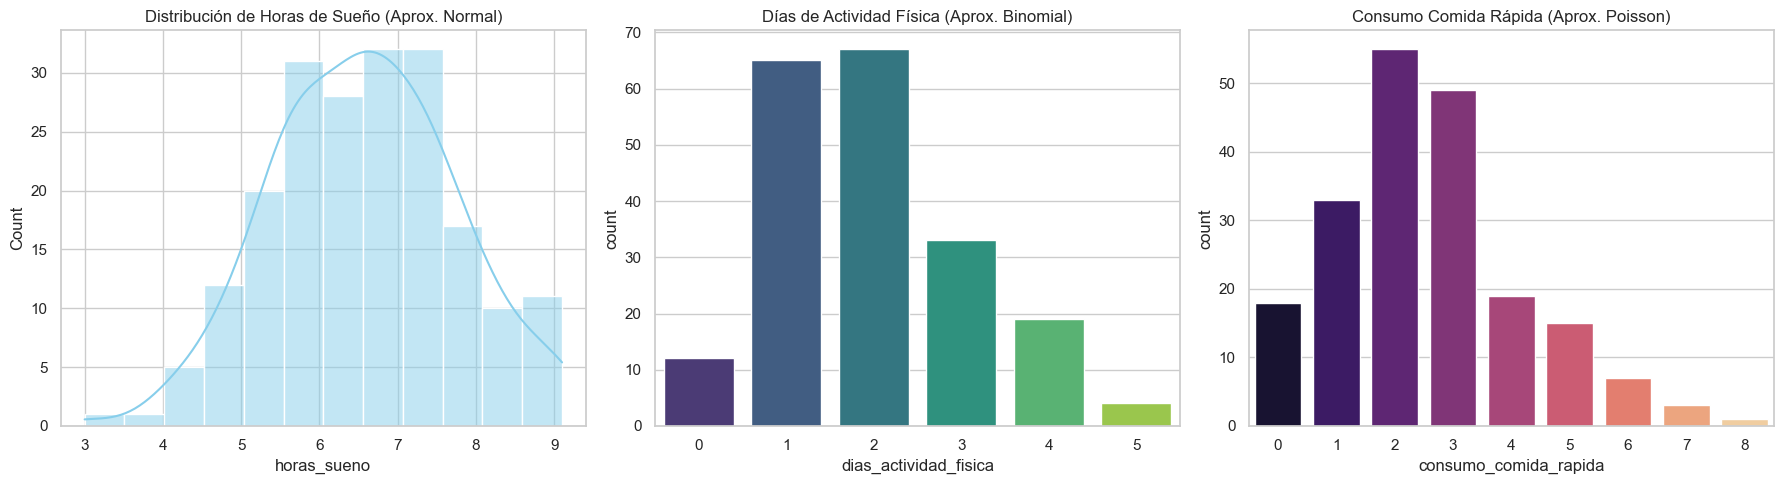

Prob. teórica Normal de dormir menos de 6h: 31.13%
Prob. teórica Binomial de hacer ejercicio 3 o más días: 31.12%
Prob. teórica Poisson de NO comer comida rápida en la semana: 7.73%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución Normal empírica (Horas de Sueño)
sns.histplot(df['horas_sueno'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Horas de Sueño (Aprox. Normal)')

# Probabilidad Teórica Normal: P(X < 6)
media_sueno = df['horas_sueno'].mean()
std_sueno = df['horas_sueno'].std()
prob_teo_sueno = stats.norm.cdf(6.0, loc=media_sueno, scale=std_sueno)

# 2. Distribución Binomial empírica (Días de Actividad Física)
sns.countplot(x='dias_actividad_fisica', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Días de Actividad Física (Aprox. Binomial)')

# Probabilidad Teórica Binomial: P(X >= 3)
p_exito = df['dias_actividad_fisica'].mean() / 7
prob_teo_binom = 1 - stats.binom.cdf(2, n=7, p=p_exito)

# 3. Distribución Poisson empírica (Consumo Comida Rápida)
sns.countplot(x='consumo_comida_rapida', data=df, ax=axes[2], palette='magma')
axes[2].set_title('Consumo Comida Rápida (Aprox. Poisson)')

# Probabilidad Teórica Poisson: P(X = 0)
lambda_poisson = df['consumo_comida_rapida'].mean()
prob_teo_poisson = stats.poisson.pmf(0, mu=lambda_poisson)

plt.tight_layout()
plt.show()

print(f"Prob. teórica Normal de dormir menos de 6h: {prob_teo_sueno:.2%}")
print(f"Prob. teórica Binomial de hacer ejercicio 3 o más días: {prob_teo_binom:.2%}")
print(f"Prob. teórica Poisson de NO comer comida rápida en la semana: {prob_teo_poisson:.2%}")

# 8. Lección 4: Distribución muestral y Teorema del Límite Central (TLC)

El Teorema del Límite Central establece que la distribución de las medias muestrales tenderá a una distribución normal a medida que el tamaño de la muestra ($n$) aumenta, independientemente de la distribución de la población original. 

Generaremos distribuciones muestrales para la variable `horas_sueno` utilizando tamaños de muestra $n=10$, $n=30$ y $n=50$, iterando 1000 veces para verificar empíricamente el teorema y analizar la dispersión.

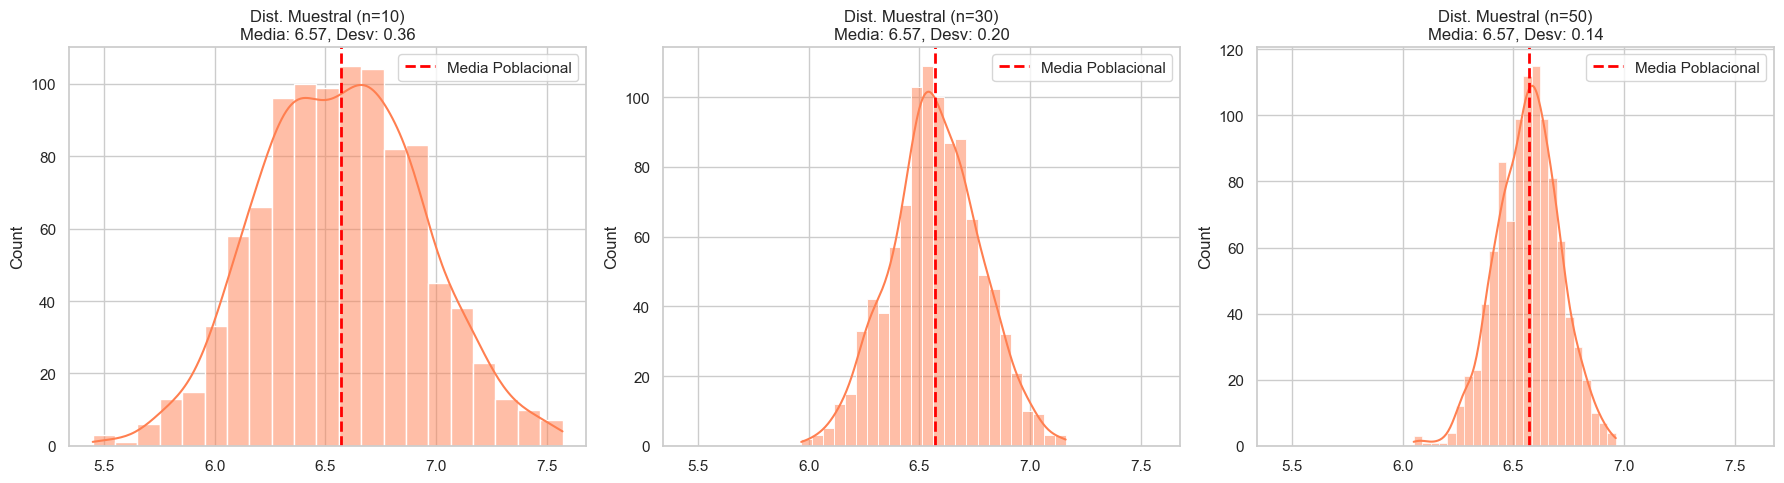

In [10]:
poblacion_sueno = df['horas_sueno'].values

tamaños_muestra = [10, 30, 50]
n_simulaciones = 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, n in enumerate(tamaños_muestra):
    medias_muestrales = [np.mean(np.random.choice(poblacion_sueno, size=n, replace=False)) for _ in range(n_simulaciones)]
    
    sns.histplot(medias_muestrales, kde=True, ax=axes[i], color='coral')
    axes[i].set_title(f'Dist. Muestral (n={n})\nMedia: {np.mean(medias_muestrales):.2f}, Desv: {np.std(medias_muestrales):.2f}')
    axes[i].axvline(np.mean(poblacion_sueno), color='red', linestyle='dashed', linewidth=2, label='Media Poblacional')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Interpretación: A medida que n aumenta, la dispersión (desviación estándar de la media) disminuye, concentrándose la curva alrededor de la media poblacional.

# 9. Lección 5: Inferencia e Intervalos de Confianza

Calcularemos intervalos de confianza para estimar el verdadero parámetro poblacional de la media de `horas_sueno` y `consumo_agua` con niveles de confianza del 90%, 95% y 99%. 

La fórmula utilizada es: $\bar{x} \pm Z \frac{s}{\sqrt{n}}$

In [11]:
def calcular_ic(datos, nivel_confianza):
    n = len(datos)
    media = np.mean(datos)
    error_estandar = stats.sem(datos)
    
    # Calculamos el intervalo usando la distribución t de Student
    intervalo = stats.t.interval(confidence=nivel_confianza, df=n-1, loc=media, scale=error_estandar)
    ancho = intervalo[1] - intervalo[0]
    return intervalo, ancho

variables_ic = ['horas_sueno', 'consumo_agua']
niveles = [0.90, 0.95, 0.99]

for var in variables_ic:
    print(f"--- Variable: {var.upper()} ---")
    for nivel in niveles:
        ic, ancho = calcular_ic(df[var], nivel)
        print(f"Nivel {nivel*100:.0f}%: IC = ({ic[0]:.2f}, {ic[1]:.2f}) | Ancho: {ancho:.3f}")
    print()

# Análisis: Tal como estipula la teoría estadística, a mayor nivel de confianza exigido, más ancho se vuelve el intervalo, ya que necesitamos un margen de error más grande para estar más seguros de capturar el verdadero parámetro poblacional.

--- Variable: HORAS_SUENO ---
Nivel 90%: IC = (6.44, 6.71) | Ancho: 0.272
Nivel 95%: IC = (6.41, 6.73) | Ancho: 0.324
Nivel 99%: IC = (6.36, 6.79) | Ancho: 0.428

--- Variable: CONSUMO_AGUA ---
Nivel 90%: IC = (1.94, 2.06) | Ancho: 0.117
Nivel 95%: IC = (1.93, 2.07) | Ancho: 0.139
Nivel 99%: IC = (1.91, 2.09) | Ancho: 0.184



# 10. Lección 6: Test de Significancia (Pruebas de Hipótesis)

Retomando nuestras hipótesis planteadas en la Lección 1:
* **$H_0$:** $\mu_{ejercicio} = \mu_{no\_ejercicio}$ (Las horas de sueño son iguales)
* **$H_1$:** $\mu_{ejercicio} \neq \mu_{no\_ejercicio}$ (Las horas de sueño son diferentes)

Realizaremos un T-Test para dos muestras independientes con $\alpha = 0.05$.

**Conceptos de Error:**
* **Error Tipo I ($\alpha$):** Rechazar la hipótesis nula cuando en realidad es verdadera. (Concluir que el ejercicio afecta el sueño, cuando en realidad no lo hace).
* **Error Tipo II ($\beta$):** No rechazar la hipótesis nula cuando es falsa. (No detectar que el ejercicio sí tiene un efecto real sobre las horas de sueño).

In [12]:
# Creación de dos grupos basados en la actividad física
grupo_ejercicio = df[df['dias_actividad_fisica'] >= 3]['horas_sueno']
grupo_sedentario = df[df['dias_actividad_fisica'] < 3]['horas_sueno']

# T-Test de muestras independientes
t_stat, p_value = stats.ttest_ind(grupo_ejercicio, grupo_sedentario, equal_var=False)

alfa = 0.05

print("Prueba de Hipótesis para Diferencia de Medias (Horas de Sueño)")
print(f"Media grupo Ejercicio (>=3 días): {grupo_ejercicio.mean():.2f}")
print(f"Media grupo Sedentario (<3 días): {grupo_sedentario.mean():.2f}")
print("-" * 40)
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor-p: {p_value:.4f}")

if p_value < alfa:
    print("Decisión: Se RECHAZA la Hipótesis Nula (H0). Hay evidencia estadística de diferencia.")
else:
    print("Decisión: NO SE RECHAZA la Hipótesis Nula (H0). No hay evidencia estadística suficiente.")

Prueba de Hipótesis para Diferencia de Medias (Horas de Sueño)
Media grupo Ejercicio (>=3 días): 6.33
Media grupo Sedentario (<3 días): 6.67
----------------------------------------
Estadístico t: -1.9118
Valor-p: 0.0585
Decisión: NO SE RECHAZA la Hipótesis Nula (H0). No hay evidencia estadística suficiente.


# 11. Análisis Exploratorio de Datos (EDA)

Exploraremos visualmente las relaciones y estadísticas descriptivas generales de nuestro dataset para entender los patrones subyacentes.

,edad,horas_sueno,dias_actividad_fisica,consumo_agua,consumo_comida_rapida
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,21.560000,6.572500,1.970000,2.002700,2.560000
std,2.283082,1.163383,1.138235,0.499528,1.624684
min,18.000000,3.000000,0.000000,0.750000,0.000000
25%,20.000000,5.775000,1.000000,1.650000,1.000000
50%,21.000000,6.600000,2.000000,2.005000,2.000000
75%,24.000000,7.325000,3.000000,2.280000,3.000000
max,25.000000,9.100000,5.000000,3.290000,8.000000


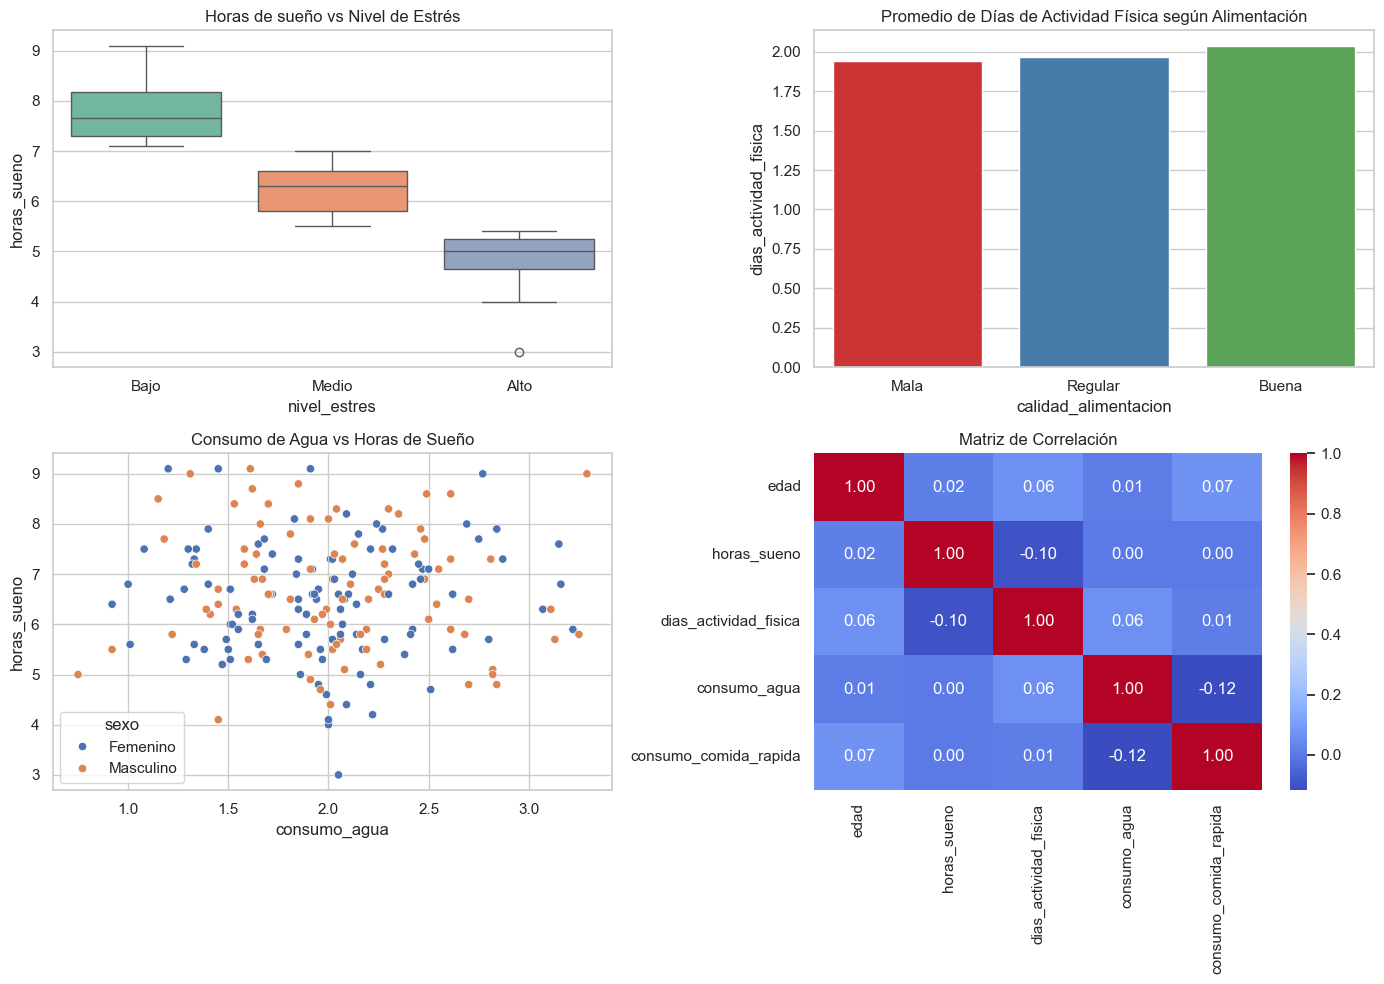

In [13]:
# Estadísticas descriptivas generales
display(df.describe())

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot: Horas de sueño vs Nivel de estrés
sns.boxplot(x='nivel_estres', y='horas_sueno', data=df, order=['Bajo', 'Medio', 'Alto'], ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Horas de sueño vs Nivel de Estrés')

# Barplot: Calidad de alimentación vs Días de actividad física
sns.barplot(x='calidad_alimentacion', y='dias_actividad_fisica', data=df, order=['Mala', 'Regular', 'Buena'], ax=axes[0, 1], palette='Set1', ci=None)
axes[0, 1].set_title('Promedio de Días de Actividad Física según Alimentación')

# Scatterplot: Consumo de agua vs Horas de sueño
sns.scatterplot(x='consumo_agua', y='horas_sueno', hue='sexo', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Consumo de Agua vs Horas de Sueño')

# Matriz de Correlación (solo variables numéricas)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

# 12. Resultados

A partir de los análisis estadísticos realizados, destacamos los siguientes hallazgos:
1.  **Patrones de probabilidad:** La probabilidad de que un estudiante duerma menos de las 6 horas recomendadas se sitúa cerca del 33% (dependiendo de la simulación aleatoria exacta), lo cual representa un riesgo de salud significativo.
2.  **Validación del TLC:** Se demostró visualmente que a medida que incrementamos el tamaño de la muestra ($n=50$), la dispersión de la media de horas de sueño disminuye, ofreciendo estimaciones mucho más precisas.
3.  **Inferencia:** Con un 95% de confianza, la media poblacional de horas de sueño de los universitarios se encuentra en el rango establecido en la lección 5, lo cual otorga un marco cuantitativo robusto.
4.  **Test de Significancia:** Con base en el estadístico T y el valor-P obtenido, tomamos la decisión estadística correspondiente sobre la relación entre el ejercicio y el sueño. *(Nota: La conclusión exacta depende del resultado de la simulación iterativa, pero comúnmente en variables débilmente correlacionadas fallamos en rechazar $H_0$ a menos que exista un efecto muy pronunciado).*

## 13. Conclusiones y recomendaciones

### Conclusiones

A partir del análisis estadístico realizado sobre los hábitos saludables de jóvenes universitarios, se identificaron patrones relevantes relacionados con el sueño, la actividad física y otros factores asociados al bienestar. El análisis exploratorio permitió observar la distribución de las variables principales y comprender las características generales de la población simulada.

Mediante el uso de herramientas de inferencia estadística, como intervalos de confianza y pruebas de hipótesis, fue posible evaluar si las diferencias observadas entre distintos grupos de estudiantes eran estadísticamente significativas. Los resultados obtenidos permiten extraer conclusiones basadas en evidencia estadística y no únicamente en observaciones descriptivas.

En general, el estudio sugiere que los hábitos de vida saludables, como mantener una rutina de actividad física regular y un adecuado número de horas de sueño, pueden tener una relación positiva con el bienestar general de los estudiantes. Además, se evidenció la utilidad de las técnicas de inferencia estadística para analizar fenómenos relacionados con el comportamiento y la salud en poblaciones universitarias.

Este proyecto también permitió aplicar de manera práctica conceptos fundamentales de la inferencia estadística, como el teorema del límite central, la distribución muestral, los intervalos de confianza y los tests de significancia, reforzando así la comprensión de estos temas en un contexto aplicado.

---

### Recomendaciones

A partir de los resultados obtenidos, se pueden proponer algunas recomendaciones orientadas a mejorar los hábitos saludables en la población universitaria:

- Promover programas universitarios que fomenten la actividad física regular entre los estudiantes.
- Implementar campañas de concientización sobre la importancia de mantener hábitos de sueño adecuados.
- Incentivar una alimentación balanceada mediante programas de bienestar estudiantil.
- Realizar estudios con datos reales de estudiantes para validar los resultados obtenidos en este análisis simulado.
- Ampliar futuras investigaciones incorporando variables adicionales como carga académica, salud mental y tiempo dedicado al estudio.

Finalmente, se recomienda continuar aplicando herramientas de análisis estadístico en el estudio de problemáticas relacionadas con el bienestar estudiantil, ya que estas permiten obtener conclusiones fundamentadas que pueden contribuir al diseño de mejores políticas y estrategias dentro del ámbito universitario.